# Diabetes 130-US Hospitals : segmentation (k = 3) et classification du risque de réadmission

Le jeu de test est lu une seule fois, à la fin ; modèle et seuils sont choisis en validation croisée.

## I. Compréhension du métier

**Contexte.** 101 766 séjours de patients diabétiques dans 130 hôpitaux américains, 1999 à 2008 (UCI, Strack et al.
2014). Une réadmission dans les 30 jours coûte cher et signale souvent une sortie mal préparée.

**État de l'art.** Sur ce fichier, les modèles publiés plafonnent entre 0,60 et 0,70 de ROC-AUC. Variables qui
ressortent : hospitalisations antérieures, durée du séjour, nombre de diagnostics, ajustement du traitement.

**BO 1.** Décrire les profils de patients pour adapter le suivi. → **DSO 1** : segmentation K-Means, validée après
coup par le taux de réadmission.

**BO 2.** Repérer, à la sortie, les patients à suivre en priorité. → **DSO 2** : classification supervisée ; succès
si au moins 18 % de réadmis parmi les 10 % de scores les plus élevés (taux de base 9,0 %).

**Mesures.**
- *Précision top 10 %* : part de réadmis parmi les 10 % de scores les plus élevés ; c'est le critère métier, car
  l'hôpital ne peut suivre qu'une liste courte.
- *Lift* : cette précision divisée par le taux de base ; 2 = deux fois mieux qu'une liste tirée au hasard.
- *ROC-AUC* : probabilité qu'un réadmis ait un score plus élevé qu'un non-réadmis (0,5 = hasard, 1 = parfait).
- *PR-AUC* : aire sous la courbe précision-rappel ; au hasard, elle vaut le taux de base (0,09).
- *Rappel* : part des réadmis retrouvés ; *précision* : part de réadmis parmi les signalés ; *F1* : leur moyenne
  harmonique.
- *Erreur-type* : variation d'un chiffre d'un pli de validation à l'autre.

## II. Compréhension des données

Chaque figure donne une décision pour la phase III.

In [1]:
import json, math, re
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, Markdown, Image

K = 3
DATA = next((p / "data" for p in [Path.cwd(), *Path.cwd().parents] if (p / "data" / "diabetic_data.csv").exists()), Path("."))
OUT = DATA.parent / "analysis" / "figures_modelisation"; OUT.mkdir(parents=True, exist_ok=True)
PFX = f"nbk{K}_"          # préfixe des figures écrites par ce notebook
RS = 42
plt.rcParams.update({"figure.dpi": 110, "axes.spines.top": False, "axes.spines.right": False, "axes.grid": True, "grid.alpha": 0.25, "font.size": 10})
BLEU, ORANGE, GRIS, VERT = "#2a78d6", "#eb6834", "#52514e", "#3a9d5d"
fr = lambda s: re.sub(r"(?<=\d)\.(?=\d)", ",", s)   # virgule décimale dans les textes

# lecture du fichier brut : seul « ? » est une valeur manquante
raw = pd.read_csv(DATA / "diabetic_data.csv", keep_default_na=False, na_values=["?"], low_memory=False)
assert raw.shape == (101766, 50)
cols_meds_23 = ["metformin", "repaglinide", "nateglinide", "chlorpropamide", "glimepiride", "acetohexamide", "glipizide", "glyburide",
                "tolbutamide", "pioglitazone", "rosiglitazone", "acarbose", "miglitol", "troglitazone", "tolazamide", "examide", "citoglipton",
                "insulin", "glyburide-metformin", "glipizide-metformin", "glimepiride-pioglitazone", "metformin-rosiglitazone", "metformin-pioglitazone"]
num_brut = ["time_in_hospital", "num_lab_procedures", "num_procedures", "num_medications", "number_outpatient", "number_emergency", "number_inpatient", "number_diagnoses"]
print("Séjours :", raw.shape[0], "| colonnes :", raw.shape[1], "| patients :", raw["patient_nbr"].nunique()); raw.head(3)

Séjours : 101766 | colonnes : 50 | patients : 71518


,encounter_id,patient_nbr,race,gender,age,weight,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,...,citoglipton,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,readmitted
0,2278392,8222157,Caucasian,Female,[0-10),NaN,6,25,1,1,...,No,No,No,No,No,No,No,No,No,NO
1,149190,55629189,Caucasian,Female,[10-20),NaN,1,1,7,3,...,No,Up,No,No,No,No,No,Ch,Yes,>30
2,64410,86047875,AfricanAmerican,Female,[20-30),NaN,1,1,7,2,...,No,No,No,No,No,No,No,No,Yes,NO


**Les variables** (50 colonnes, une ligne = un séjour) :

| Groupe | Variables |
|---|---|
| Identifiants | `encounter_id` (séjour), `patient_nbr` (patient) |
| Patient | `race`, `gender`, `age` (tranches de 10 ans), `weight` |
| Séjour | `admission_type_id`, `admission_source_id`, `discharge_disposition_id`, `time_in_hospital`, `medical_specialty`, `payer_code` |
| Soins pendant le séjour | `num_lab_procedures`, `num_procedures`, `num_medications`, `number_diagnoses`, `diag_1`, `diag_2`, `diag_3` |
| Année précédente | `number_outpatient` (consultations), `number_emergency` (urgences), `number_inpatient` (hospitalisations) |
| Diabète | `A1Cresult`, `max_glu_serum`, 23 médicaments (No / Steady / Up / Down), `change`, `diabetesMed` |
| **Cible** | `readmitted` : NO, >30, <30 |

### 2.1 La cible

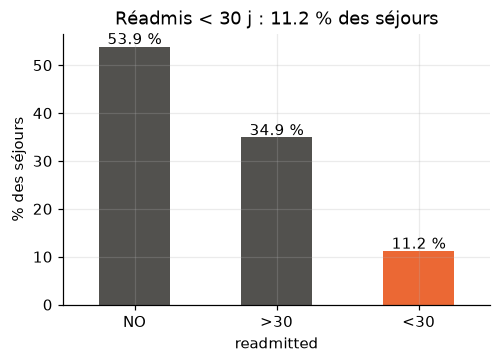

In [2]:
# répartition de readmitted sur les séjours
v = raw["readmitted"].value_counts(normalize=True).mul(100).round(1)
ax = v.plot.bar(color=[GRIS, GRIS, ORANGE], rot=0, figsize=(5, 3.2)); ax.set(ylabel="% des séjours", title=f"Réadmis < 30 j : {v['<30']} % des séjours")
for i, t in enumerate(v): ax.text(i, t + 0.5, f"{t} %", ha="center")
plt.show()

Classe rare : 11 % des séjours, 9 % des patients. Décision : poids de classes, et un critère sur liste (précision
top 10 %) plutôt que l'exactitude, qui vaudrait 91 % pour un modèle qui ne signale personne.

### 2.2 Séjours par patient

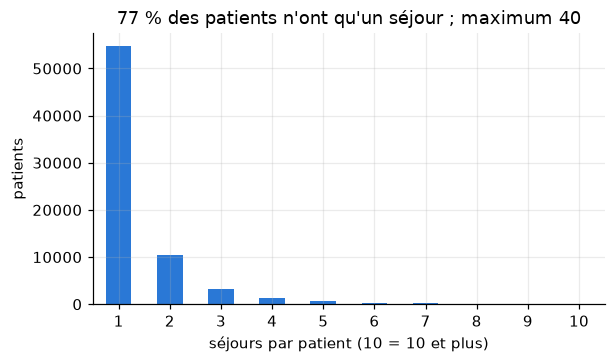

In [3]:
# nombre de séjours par patient
n_sej = raw["patient_nbr"].value_counts()
ax = n_sej.clip(upper=10).value_counts().sort_index().plot.bar(color=BLEU, rot=0, figsize=(6, 3.2))
ax.set(xlabel="séjours par patient (10 = 10 et plus)", ylabel="patients", title=f"{(n_sej == 1).mean()*100:.0f} % des patients n'ont qu'un séjour ; maximum {n_sej.max()}")
plt.show()

Un patient sur quatre revient. Décision : garder le premier séjour de chaque patient, pour qu'aucun patient ne soit à
la fois en apprentissage et en test.

### 2.3 Valeurs manquantes

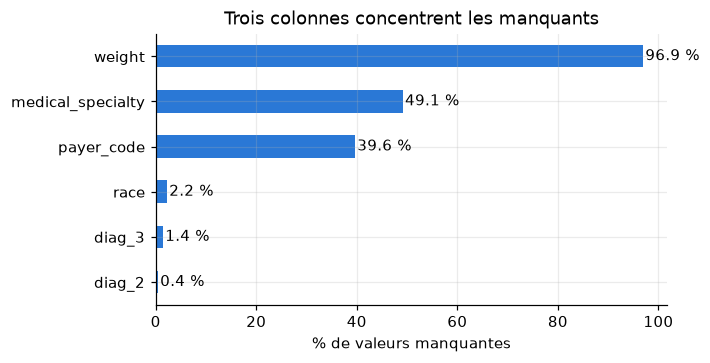

In [4]:
# part de valeurs manquantes par colonne (colonnes concernées seulement)
manq = raw.isna().mean().mul(100).round(1); manq = manq[manq > 0].sort_values()
ax = manq.plot.barh(color=BLEU, figsize=(6, 3.2)); ax.set(xlabel="% de valeurs manquantes", title="Trois colonnes concentrent les manquants")
for i, t in enumerate(manq): ax.text(t + 0.5, i, f"{t} %", va="center")
plt.show()

Décisions : `weight` et `payer_code` supprimées ; `medical_specialty` et `race` → « Inconnu » ; diagnostics
secondaires → « Aucun » ; diagnostic principal manquant → ligne retirée.

### 2.4 Âge

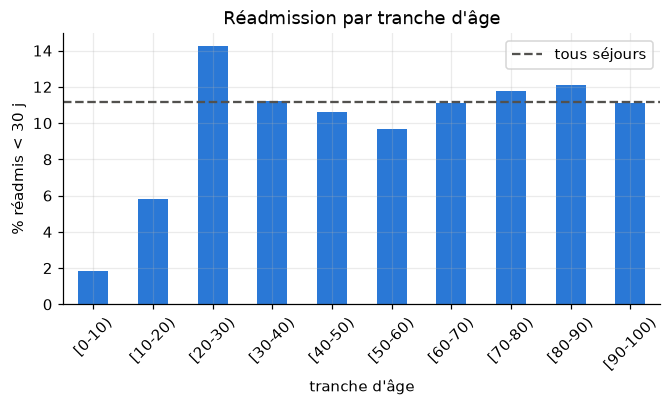

In [5]:
# taux de réadmission par tranche d'âge
r30 = raw["readmitted"].eq("<30")
t = r30.groupby(raw["age"]).mean().mul(100)
ax = t.plot.bar(color=BLEU, rot=45, figsize=(7, 3.2), label="_nolegend_"); ax.axhline(r30.mean() * 100, ls="--", color=GRIS, label="tous séjours"); ax.legend()
ax.set(ylabel="% réadmis < 30 j", xlabel="tranche d'âge", title="Réadmission par tranche d'âge"); plt.show()

Taux bas avant 20 ans, pic à 14 % sur la petite tranche 20-30 ans, puis 10 à 12 %. Décision : l'âge devient un rang
de 0 à 9.

Trois autres variables :

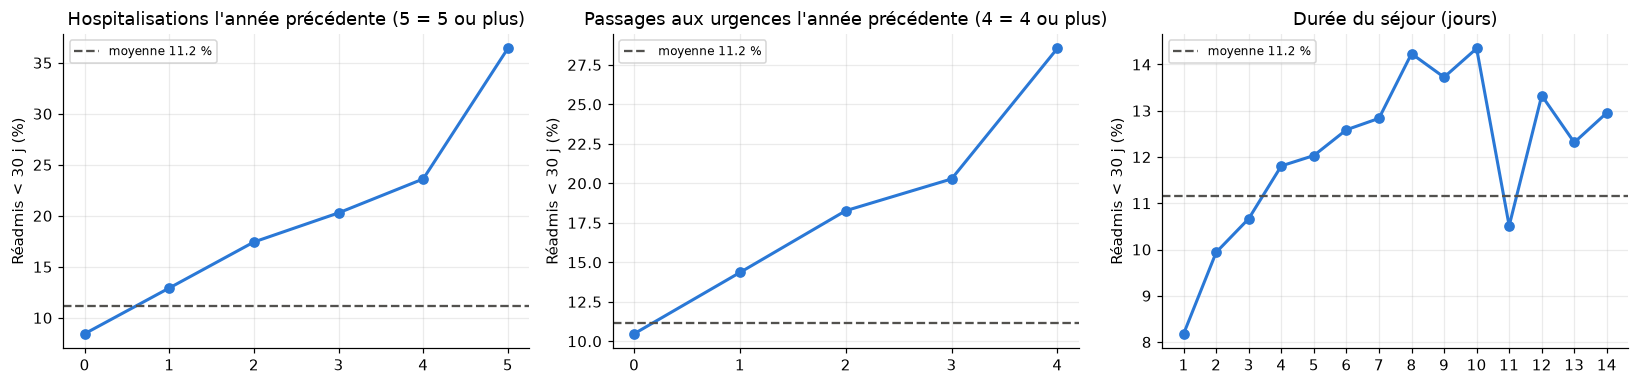

In [6]:
# taux de réadmission selon trois autres variables
facteurs = {"Hospitalisations l'année précédente (5 = 5 ou plus)": raw["number_inpatient"].clip(upper=5),
            "Passages aux urgences l'année précédente (4 = 4 ou plus)": raw["number_emergency"].clip(upper=4),
            "Durée du séjour (jours)": raw["time_in_hospital"]}

fig, axs = plt.subplots(1, 3, figsize=(15, 3.6))
for ax, (titre, x) in zip(axs, facteurs.items()):
    taux = r30.groupby(x).mean() * 100
    ax.plot(taux.index.astype(str), taux.values, "-o", color=BLEU, lw=2)
    ax.axhline(r30.mean() * 100, ls="--", color=GRIS, label=f"moyenne {r30.mean() * 100:.1f} %")
    ax.set(title=titre, ylabel="Réadmis < 30 j (%)")
    ax.legend(fontsize=8)
fig.tight_layout()
plt.show()

**Lecture :**
- **Hospitalisations antérieures** : de 8,4 % (aucune) à 36,4 % (5 ou plus), le facteur le plus net.
- **Urgences antérieures** : de 10,5 % à 28,5 %.
- **Durée du séjour** : de 8,2 % (1 jour) à environ 14 % (8 à 10 jours).

### 2.5 HbA1c et diagnostic principal

,non testée,testée
autre diagnostic,11.2,9.9
diabète principal,14.6,9.5


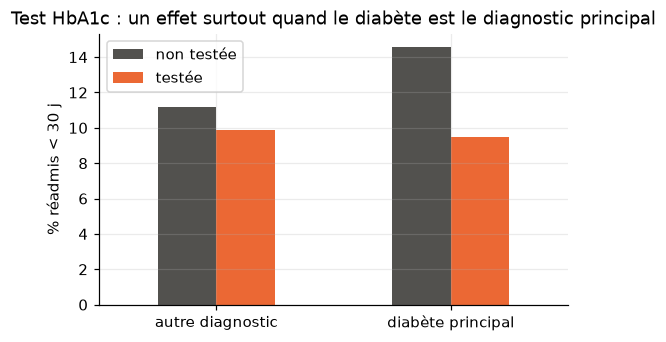

In [7]:
# effet du test HbA1c selon que le diabète est le diagnostic principal ou non
d = pd.DataFrame({"r30": r30, "diabète principal": raw["diag_1"].astype(str).str.startswith("250"), "HbA1c testée": raw["A1Cresult"].ne("None")})
t = d.groupby(["diabète principal", "HbA1c testée"])["r30"].mean().mul(100).round(1).unstack()
t.index = ["autre diagnostic", "diabète principal"]; t.columns = ["non testée", "testée"]; display(t)
ax = t.plot.bar(rot=0, color=[GRIS, ORANGE], figsize=(5.5, 3.2)); ax.set(ylabel="% réadmis < 30 j", title="Test HbA1c : un effet surtout quand le diabète est le diagnostic principal"); plt.show()

Décision : `A1Cresult` garde sa modalité « Non testé », qui porte une information (le suivi n'a pas été fait).

### 2.6 Insuline

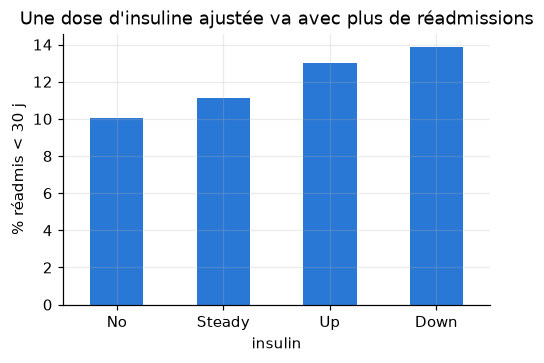

In [8]:
# réadmission selon la modalité de l'insuline
t = r30.groupby(raw["insulin"]).mean().mul(100).reindex(["No", "Steady", "Up", "Down"])
ax = t.plot.bar(color=BLEU, rot=0, figsize=(5, 3.2)); ax.set(ylabel="% réadmis < 30 j", title="Une dose d'insuline ajustée va avec plus de réadmissions"); plt.show()

Décision : les médicaments gardent leurs quatre modalités (No, Steady, Up, Down) ; les réduire à oui / non
effacerait ce signal.

### 2.7 Usage des 23 médicaments

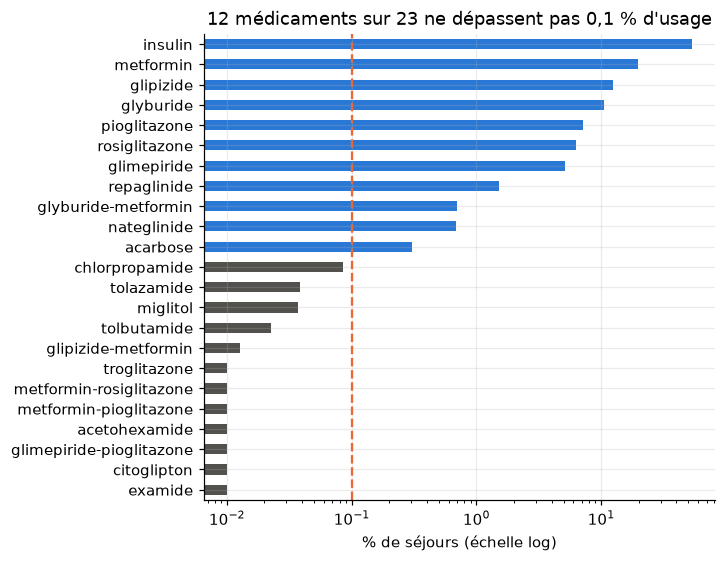

In [9]:
# part de séjours où chaque médicament est présent (échelle log ; 0 % affiché à 0,01 %)
part = (raw[cols_meds_23] != "No").mean().mul(100).sort_values()
ax = part.clip(lower=0.01).plot.barh(color=[GRIS if p <= 0.1 else BLEU for p in part], figsize=(6, 5.5), logx=True)
ax.axvline(0.1, ls="--", color=ORANGE); ax.set(xlabel="% de séjours (échelle log)", title=f"{(part <= 0.1).sum()} médicaments sur 23 ne dépassent pas 0,1 % d'usage")
plt.show()

Décision : les douze médicaments sous 0,1 % d'usage sont supprimés.

### 2.8 Corrélations entre variables numériques

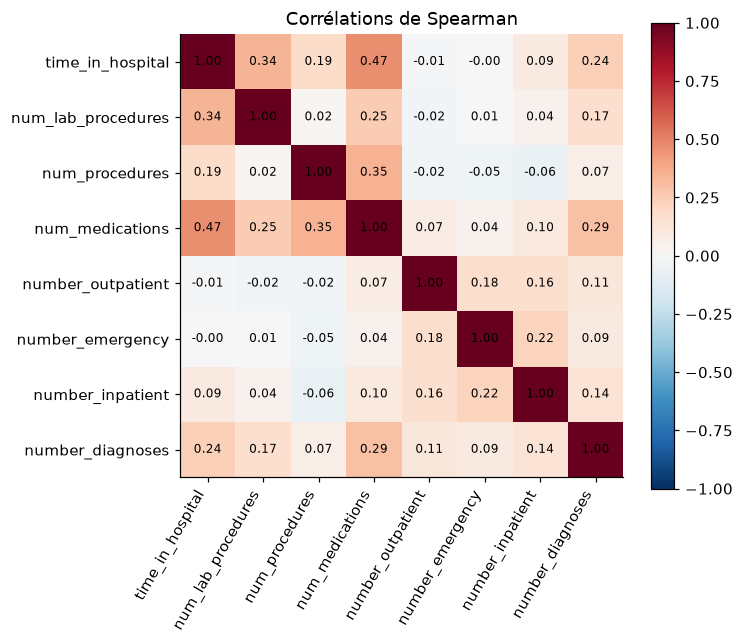

In [10]:
# corrélations de Spearman entre les huit compteurs
corr = raw[num_brut].corr(method="spearman")
fig, ax = plt.subplots(figsize=(6.5, 5.5)); im = ax.imshow(corr, cmap="RdBu_r", vmin=-1, vmax=1); ax.grid(False)
ax.set_xticks(range(len(num_brut)), num_brut, rotation=60, ha="right"); ax.set_yticks(range(len(num_brut)), num_brut)
for i in range(len(num_brut)):
    for j in range(len(num_brut)): ax.text(j, i, f"{corr.iloc[i, j]:.2f}", ha="center", va="center", fontsize=8)
fig.colorbar(im, ax=ax); ax.set_title("Corrélations de Spearman"); plt.show()

Corrélations faibles. Décision : aucune variable retirée ; les trois compteurs de visites restent séparés (recours de
nature différente).

### 2.9 Distribution des compteurs

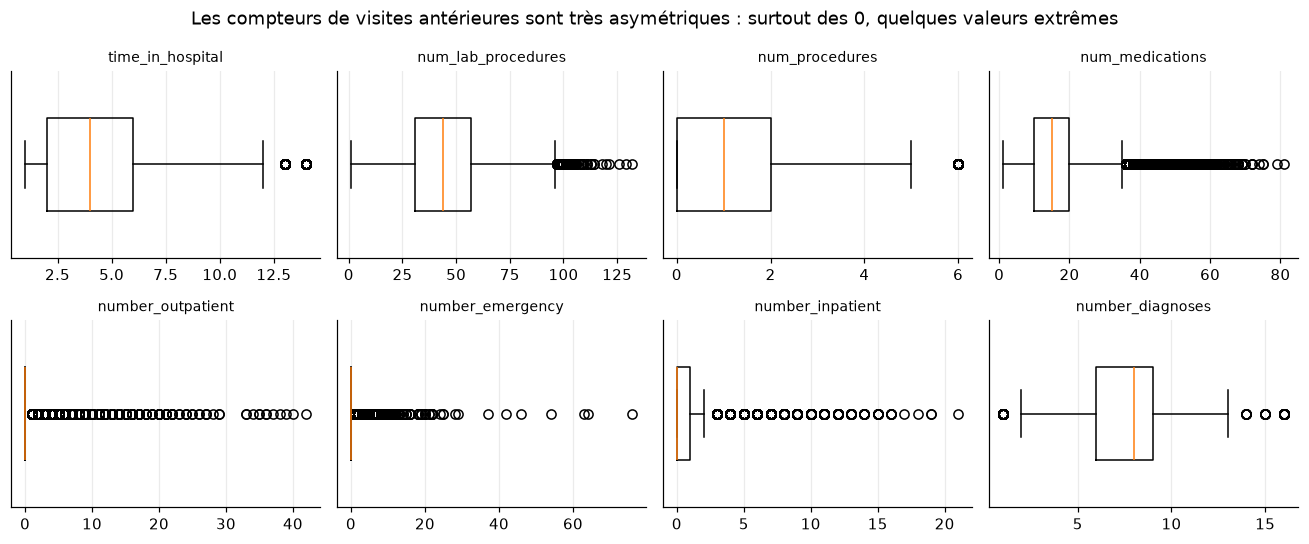

In [11]:
# boîtes à moustaches des huit compteurs
fig, axs = plt.subplots(2, 4, figsize=(12, 5))
for ax, c in zip(axs.ravel(), num_brut): ax.boxplot(raw[c], orientation="horizontal", widths=0.5); ax.set_title(c, fontsize=9); ax.set_yticks([])
fig.suptitle("Les compteurs de visites antérieures sont très asymétriques : surtout des 0, quelques valeurs extrêmes"); fig.tight_layout(); plt.show()

Décision : log1p sur les compteurs asymétriques avant le K-Means (distance sensible aux extrêmes).

## III. Préparation des données

### 3.1 Variables dérivées
`total_visits` (somme des visites antérieures), `nb_meds_used` (médicaments du diabète actifs), `nb_med_changes`
(doses modifiées).

In [12]:
df = raw.copy(); etapes = {"séjours bruts": len(df)}
df["total_visits"] = df["number_outpatient"] + df["number_emergency"] + df["number_inpatient"]
df["nb_meds_used"] = (df[cols_meds_23] != "No").sum(axis=1)
df["nb_med_changes"] = df[cols_meds_23].isin(["Up", "Down"]).sum(axis=1)
print("Séjours :", len(df)); df[["total_visits", "nb_meds_used", "nb_med_changes"]].describe().round(2)

Séjours : 101766


,total_visits,nb_meds_used,nb_med_changes
count,101766.00,101766.00,101766.00
mean,1.20,1.18,0.29
std,2.29,0.92,0.49
min,0.00,0.00,0.00
25%,0.00,1.00,0.00
50%,0.00,1.00,0.00
75%,2.00,2.00,1.00
max,80.00,6.00,4.00


### 3.2 Exclusions et déduplication
Retirés : décès et soins palliatifs (codes de sortie 11, 13, 14, 19, 20, 21 ; pas de réadmission possible), genre
invalide (3 lignes), diagnostic principal manquant (10 lignes). Gardé : le premier séjour de chaque patient.

In [13]:
n0 = len(df)
df = df[~df["discharge_disposition_id"].isin([11, 13, 14, 19, 20, 21])].copy()
print("Exclusions décès / soins palliatifs :", n0 - len(df), "lignes ->", len(df)); assert n0 - len(df) == 2423; etapes["sans décès / soins palliatifs"] = len(df)
df = df.sort_values(["patient_nbr", "encounter_id"]).drop_duplicates(subset="patient_nbr", keep="first").copy()
print("Premier séjour par patient :", len(df)); assert len(df) == 69990; etapes["premier séjour par patient"] = len(df)
df = df[df["gender"] != "Unknown/Invalid"].copy(); assert len(df) == 69987; etapes["genre connu"] = len(df)
df = df[df["diag_1"].notna()].copy(); assert len(df) == 69977; etapes["diagnostic principal connu"] = len(df)
print("Cohorte finale :", len(df), "patients")

Exclusions décès / soins palliatifs : 2423 lignes -> 99343
Premier séjour par patient : 69990


Cohorte finale : 69977 patients


### 3.3 Valeurs manquantes
`weight` (97 % vide) et `payer_code` (40 %) supprimées ; `race` et `medical_specialty` manquantes → « Inconnu » ;
`A1Cresult` et `max_glu_serum` non mesurés → « Non testé ».

In [14]:
manq = df.isna().sum(); display(manq[manq > 0].sort_values(ascending=False).to_frame("manquants"))
df = df.drop(columns=["weight", "payer_code"])
df["race"] = df["race"].fillna("Inconnu"); df["medical_specialty"] = df["medical_specialty"].fillna("Inconnu")
df["A1Cresult"] = df["A1Cresult"].replace("None", "Non testé"); df["max_glu_serum"] = df["max_glu_serum"].replace("None", "Non testé")

,manquants
weight,67189
medical_specialty,33649
payer_code,30408
race,1916
diag_3,1224
diag_2,293


### 3.4 Regroupements
Admission, sortie et provenance regroupées en quelques modalités ; spécialité en 7 niveaux ; âge en rang 0 à 9 ;
diagnostics ICD-9 en 9 familles (Strack et al. 2014).

In [15]:
def map_admission(x): return {1: "Emergency", 2: "Urgent", 3: "Elective"}.get(x, "Inconnu")
def map_discharge(x):
    if x == 1: return "Home"
    if x in (6, 8): return "Home with care"
    if x == 3: return "SNF"
    if x == 22: return "Rehab"
    if x == 7: return "AMA"
    if x in (18, 25, 26): return "Inconnu"
    return "Other"
def map_source(x):
    if x in (1, 2, 3): return "Referral"
    if x == 7: return "Emergency room"
    if x in (4, 5, 6, 10, 18, 22, 25, 26): return "Transfer"
    return "Inconnu"
def group_specialty(x):
    if x == "Inconnu": return "Inconnu"
    if x in ("InternalMedicine", "Family/GeneralPractice"): return x
    if "Emergency/Trauma" in x: return "Emergency/Trauma"
    if "Cardiology" in x: return "Cardiology"
    if "Surgery" in x or "Surgical" in x: return "Surgery"
    return "Other"
def group_icd9(code):
    if pd.isna(code): return "Aucun"
    code = str(code).strip()
    if code.startswith(("V", "E")): return "Autre"
    x = float(code)
    if 390 <= x < 460 or math.floor(x) == 785: return "Circulatoire"
    if 460 <= x < 520 or math.floor(x) == 786: return "Respiratoire"
    if 520 <= x < 580 or math.floor(x) == 787: return "Digestif"
    if 250 <= x < 251: return "Diabète"
    if 800 <= x < 1000: return "Traumatisme"
    if 710 <= x < 740: return "Musculo-squelettique"
    if 580 <= x < 630 or math.floor(x) == 788: return "Génito-urinaire"
    if 140 <= x < 240: return "Tumeur"
    return "Autre"

df["admission_type"] = df["admission_type_id"].apply(map_admission)
df["discharge_disposition"] = df["discharge_disposition_id"].apply(map_discharge)
df["admission_source"] = df["admission_source_id"].apply(map_source)
df["medical_specialty"] = df["medical_specialty"].apply(group_specialty)
df["age"] = df["age"].map({f"[{10*i}-{10*(i+1)})": i for i in range(10)}); assert df["age"].notna().all()
for i in (1, 2, 3): df[f"diag_{i}_group"] = df[f"diag_{i}"].apply(group_icd9)
df = df.drop(columns=["diag_1", "diag_2", "diag_3"])
pd.concat({c: df[c].value_counts() for c in ["discharge_disposition", "medical_specialty", "diag_1_group"]}, axis=1).fillna(0).astype(int)

,discharge_disposition,medical_specialty,diag_1_group
Home,44317,0,0
SNF,8788,0,0
Home with care,8363,0,0
Other,3440,8394,0
Inconnu,3251,33649,0
Rehab,1410,0,0
AMA,408,0,0
InternalMedicine,0,10640,0
Family/GeneralPractice,0,4978,0
Emergency/Trauma,0,4392,0


### 3.5 Médicaments, cible, identifiants
12 médicaments rares supprimés ; `diabetesMed` supprimée (redondante avec `nb_meds_used`) ; cible = 1 si `readmitted`
vaut « <30 » ; identifiants retirés.

In [16]:
meds_rares = ["acetohexamide", "glimepiride-pioglitazone", "metformin-pioglitazone", "metformin-rosiglitazone", "troglitazone", "glipizide-metformin",
              "tolbutamide", "miglitol", "tolazamide", "chlorpropamide", "citoglipton", "examide"]
df = df.drop(columns=meds_rares)
assert (df["diabetesMed"].eq("Yes") == (df["nb_meds_used"] > 0)).all(); df = df.drop(columns=["diabetesMed"])
df["target_readmission"] = (df["readmitted"] == "<30").astype(int)
df = df.drop(columns=["readmitted", "encounter_id", "patient_nbr", "admission_type_id", "discharge_disposition_id", "admission_source_id"]).reset_index(drop=True)
assert len(df) == 69977 and df.isna().sum().sum() == 0 and round(df["target_readmission"].mean(), 4) == 0.0898
ref = DATA / "diabetes_prepared_v2.csv"
if ref.exists():
    r = pd.read_csv(ref, keep_default_na=False, na_values=[]); assert r.shape == df.shape and list(r.columns) == list(df.columns)
    assert (r.values == df.values).all(); print("Contrôle : identique au jeu préparé de référence")
print("Shape :", df.shape, "| taux de réadmission < 30 j :", round(df["target_readmission"].mean() * 100, 2), "%")

Contrôle : identique au jeu préparé de référence
Shape : (69977, 36) | taux de réadmission < 30 j : 8.98 %


Le chemin des lignes, de 101 766 séjours à 69 977 patients :

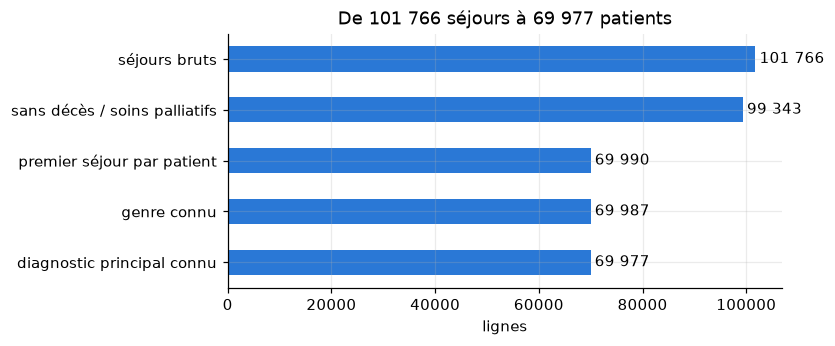

In [17]:
# effectif après chaque étape de la préparation
ax = pd.Series(etapes).plot.barh(color=BLEU, figsize=(6.5, 3)); ax.invert_yaxis()
for i, v in enumerate(etapes.values()): ax.text(v + 800, i, f"{v:,}".replace(",", " "), va="center")
ax.set(xlabel="lignes", title="De 101 766 séjours à 69 977 patients"); plt.show()

### 3.6 Feature engineering

| Variable | Construction | Statut |
|---|---|---|
| `nb_meds_used` | nb de médicaments du diabète ≠ No | gardée |
| `nb_med_changes` | nb de médicaments Up ou Down | gardée |
| `total_visits` | outpatient + emergency + inpatient | gardée, avec les trois compteurs |
| `age` | tranche de 10 ans → rang 0 à 9 | gardée |
| admission, sortie, provenance, spécialité, ICD-9 | regroupements (Strack et al. 2014) | gardés |
| `A1C_tested` | 1 si HbA1c mesurée | non ajoutée, déjà dans `A1Cresult` |
| 11 indicatrices et comptages | hospitalisation antérieure, insuline modifiée… | non retenues : top 10 % en CV 20,6 % avec, 20,7 % sans |
| 5 interactions entre variables | croisements | sans gain : ROC-AUC 0,635 contre 0,632 |
| profil K-Means | lettre du groupe | non retenu : ± 1 point |

Les ajouts testés ne déplacent pas le classement au-delà du bruit (erreur-type ≈ 0,5 point).

Taux de réadmission selon les variables créées :

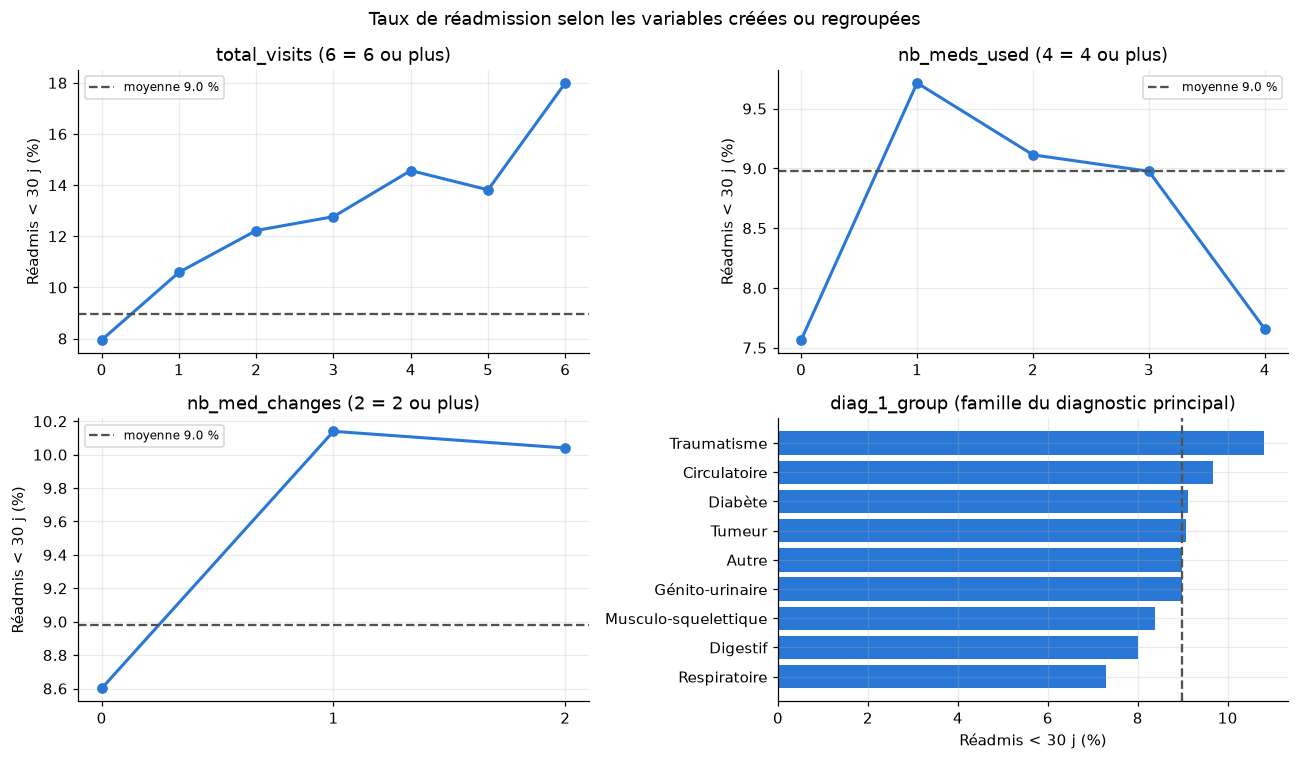

In [18]:
taux_moy = df["target_readmission"].mean() * 100
nouvelles = {"total_visits (6 = 6 ou plus)": df["total_visits"].clip(upper=6),
             "nb_meds_used (4 = 4 ou plus)": df["nb_meds_used"].clip(upper=4),
             "nb_med_changes (2 = 2 ou plus)": df["nb_med_changes"].clip(upper=2)}

fig, axs = plt.subplots(2, 2, figsize=(12, 7))
for ax, (titre, x) in zip(axs.ravel(), nouvelles.items()):
    taux = df.groupby(x)["target_readmission"].mean() * 100
    ax.plot(taux.index, taux.values, "-o", color=BLEU, lw=2)
    ax.axhline(taux_moy, ls="--", color=GRIS, label=f"moyenne {taux_moy:.1f} %")
    ax.set(title=titre, ylabel="Réadmis < 30 j (%)", xticks=taux.index)
    ax.legend(fontsize=8)

taux_diag = df.groupby("diag_1_group")["target_readmission"].mean().mul(100).sort_values()
axs[1, 1].barh(taux_diag.index, taux_diag.values, color=BLEU)
axs[1, 1].axvline(taux_moy, ls="--", color=GRIS)
axs[1, 1].set(title="diag_1_group (famille du diagnostic principal)", xlabel="Réadmis < 30 j (%)")
fig.suptitle("Taux de réadmission selon les variables créées ou regroupées")
fig.tight_layout()
plt.show()

**Lecture :**
- `total_visits` : de 7,9 % (aucune visite) à 18,0 % (6 ou plus), la plus utile.
- `nb_meds_used`, `nb_med_changes` : effet faible (7,6 à 10,1 %) ; elles servent surtout au K-Means.
- `diag_1_group` : de 7,3 % (respiratoire) à 10,8 % (traumatisme).

## IV. Modélisation, DSO 1 : segmentation des patients

### 4.1 Variables de segmentation
11 variables numériques sur trois axes : complexité clinique, recours antérieur aux soins, intensité du séjour. Ni la
cible ni le mode de sortie. log1p sur les compteurs asymétriques, puis centrage-réduction.

In [19]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, adjusted_rand_score
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split

axes = {"Complexité clinique": ["number_diagnoses", "age", "nb_meds_used", "nb_med_changes"],
        "Recours antérieur": ["number_outpatient", "number_emergency", "number_inpatient"],
        "Intensité du séjour": ["time_in_hospital", "num_lab_procedures", "num_procedures", "num_medications"]}
vars_cluster = [v for vs in axes.values() for v in vs]
noms_fr = {"number_diagnoses": "Nb de diagnostics", "age": "Âge (tranche)", "nb_meds_used": "Médicaments du diabète actifs", "nb_med_changes": "Médicaments modifiés",
           "number_outpatient": "Consultations (année préc.)", "number_emergency": "Urgences (année préc.)", "number_inpatient": "Hospitalisations (année préc.)",
           "time_in_hospital": "Durée du séjour (jours)", "num_lab_procedures": "Analyses de laboratoire", "num_procedures": "Actes (hors labo)", "num_medications": "Médicaments administrés"}
X_cluster = df[vars_cluster].astype(float).copy(); assert "target_readmission" not in X_cluster.columns
skew = X_cluster.skew(); vars_log = skew[skew > 1].index.tolist(); print("log1p appliqué à :", vars_log)
X_log = X_cluster.copy(); X_log[vars_log] = np.log1p(X_log[vars_log]); Z = StandardScaler().fit_transform(X_log)

log1p appliqué à : ['nb_med_changes', 'number_outpatient', 'number_emergency', 'number_inpatient', 'time_in_hospital', 'num_procedures', 'num_medications']


### 4.2 Choix du nombre de groupes
Pour k = 2 à 10 : **coude** (inertie), **silhouette** (de −1 à 1, séparation des groupes) et **stabilité** (ARI entre
initialisations aléatoires différentes, pour k = 3, 4, 6 ; 1 = découpages identiques).

,k,inertie,baisse vs k-1 (%),silhouette,stabilité (ARI)
0,2,669565,NaN,0.132,NaN
1,3,611473,8.7,0.138,0.99
2,4,563595,7.8,0.128,0.99
3,5,524292,7.0,0.133,NaN
4,6,489277,6.7,0.140,0.54
5,7,463228,5.3,0.121,NaN
6,8,442045,4.6,0.122,NaN
7,9,427104,3.4,0.124,NaN
8,10,412290,3.5,0.122,NaN


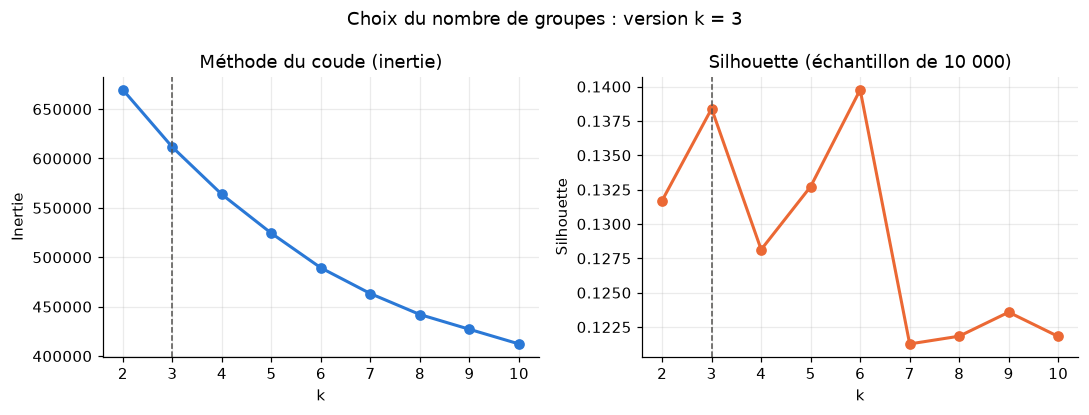

In [20]:
_, idx_sil = train_test_split(np.arange(len(Z)), test_size=10000, stratify=df["age"], random_state=RS)
ks = list(range(2, 11)); inertie, silh, labels_k = [], [], {}
for k in ks:
    km_k = KMeans(n_clusters=k, n_init=10, random_state=RS).fit(Z); labels_k[k] = km_k.labels_
    inertie.append(float(km_k.inertia_)); silh.append(float(silhouette_score(Z[idx_sil], km_k.labels_[idx_sil])))
tab_k = pd.DataFrame({"k": ks, "inertie": np.round(inertie, 0).astype(int), "baisse vs k-1 (%)": [np.nan] + [round((inertie[i-1] - inertie[i]) / inertie[i-1] * 100, 1) for i in range(1, len(ks))],
                      "silhouette": np.round(silh, 3)})
stab = {k: round(np.mean([adjusted_rand_score(labels_k[k], KMeans(k, n_init=10, random_state=s).fit(Z).labels_) for s in (1, 7)]), 2) for k in (3, 4, 6)}
tab_k["stabilité (ARI)"] = tab_k["k"].map(stab); display(tab_k)

fig, ax = plt.subplots(1, 2, figsize=(10, 3.8))
ax[0].plot(ks, inertie, "-o", color=BLEU, lw=2, ms=6); ax[0].axvline(K, color=GRIS, ls="--", lw=1); ax[0].set(title="Méthode du coude (inertie)", xlabel="k", ylabel="Inertie")
ax[1].plot(ks, silh, "-o", color=ORANGE, lw=2, ms=6); ax[1].axvline(K, color=GRIS, ls="--", lw=1); ax[1].set(title="Silhouette (échantillon de 10 000)", xlabel="k", ylabel="Silhouette")
fig.suptitle(f"Choix du nombre de groupes : version k = {K}"); fig.tight_layout(); fig.savefig(OUT / f"{PFX}fig1_coude_silhouette.png", bbox_inches="tight"); plt.show()

### Justification du choix k = 3
- **Coude** : pas de cassure (baisses de 8,7, 7,8, 7,0, 6,7 %).
- **Silhouette** : plate, 0,12 à 0,14 : les patients forment un continuum. k = 6 est à peine plus haut que k = 3
  (0,140 contre 0,138).
- **Stabilité** : ARI 0,99 pour k = 3, contre 0,54 pour k = 6.
- **Choix** : k = 3, le découpage le plus stable et le plus lisible (séjours légers, séjours lourds, passages aux
  urgences). Il est gardé tel quel, sans regroupement après coup.
- **Limite** : les patients déjà hospitalisés l'année précédente (groupe G4 de la table croisée ci-dessous : 6 089
  patients, réadmis à 16,1 %) sont isolés par k = 6 mais répartis dans les trois profils à k = 3.

In [21]:
km = KMeans(n_clusters=K, n_init=10, random_state=RS).fit(Z)
ordre = pd.Series(km.labels_).value_counts().index.tolist(); lettres = {lab: chr(65 + i) for i, lab in enumerate(ordre)}
df["profil"] = pd.Series(km.labels_).map(lettres).values          # lettres par effectif décroissant
profil = X_cluster.groupby(df["profil"])[vars_cluster].median()
profil.insert(0, "effectif", df["profil"].value_counts().sort_index()); profil.insert(1, "part (%)", (profil["effectif"] / len(df) * 100).round(1))
display(profil.T)
base_rate = df["target_readmission"].mean()
readm = df.groupby("profil")["target_readmission"].agg(taux="mean", réadmis="sum", effectif="size")
readm["taux (%)"] = (readm["taux"] * 100).round(1); readm["marge ± (95 %)"] = (196 * np.sqrt(readm["taux"] * (1 - readm["taux"]) / readm["effectif"])).round(1)
display(readm[["effectif", "réadmis", "taux (%)", "marge ± (95 %)"]])
# table croisée avec l'autre découpage : où vont les patients de chaque groupe ?
autre = 6 if K == 3 else 3
lab_autre = pd.Series(labels_k[autre]).map({lab: f"G{i + 1}" for i, lab in enumerate(pd.Series(labels_k[autre]).value_counts().index)}).values
taux_autre = (df["target_readmission"].groupby(lab_autre).mean() * 100).round(1)
croise = pd.crosstab(df["profil"].rename(f"profil (k = {K})"), lab_autre)
croise.columns = [fr(f"{g} (réadmis {taux_autre[g]} %)") for g in croise.columns]
print(f"Lignes : profils k = {K}. Colonnes : groupes obtenus avec k = {autre}, numérotés par effectif décroissant, avec leur taux de réadmission.")
display(croise)

profil,A,B,C
effectif,34198.0,30708.0,5071.0
part (%),48.9,43.9,7.2
number_diagnoses,6.0,9.0,9.0
age,6.0,7.0,6.0
nb_meds_used,1.0,1.0,1.0
nb_med_changes,0.0,0.0,0.0
number_outpatient,0.0,0.0,0.0
number_emergency,0.0,0.0,1.0
number_inpatient,0.0,0.0,0.0
time_in_hospital,2.0,6.0,3.0


,effectif,réadmis,taux (%),marge ± (95 %)
profil,,,,
A,34198,2451,7.2,0.3
B,30708,3225,10.5,0.3
C,5071,607,12.0,0.9


Lignes : profils k = 3. Colonnes : groupes obtenus avec k = 6, numérotés par effectif décroissant, avec leur taux de réadmission.


,"G1 (réadmis 9,2 %)","G2 (réadmis 6,0 %)","G3 (réadmis 9,3 %)","G4 (réadmis 16,1 %)","G5 (réadmis 8,9 %)","G6 (réadmis 11,1 %)"
profil (k = 3),,,,,,
A,7229,20791,1696,1926,2556,0
B,14535,3,9890,3873,2406,1
C,0,31,28,290,262,4460


### 4.3 Visualiser les profils

**Méthode 1 : centres standardisés et taux de réadmission.** Rouge = au-dessus de la moyenne, bleu = en dessous (en
écarts-types).

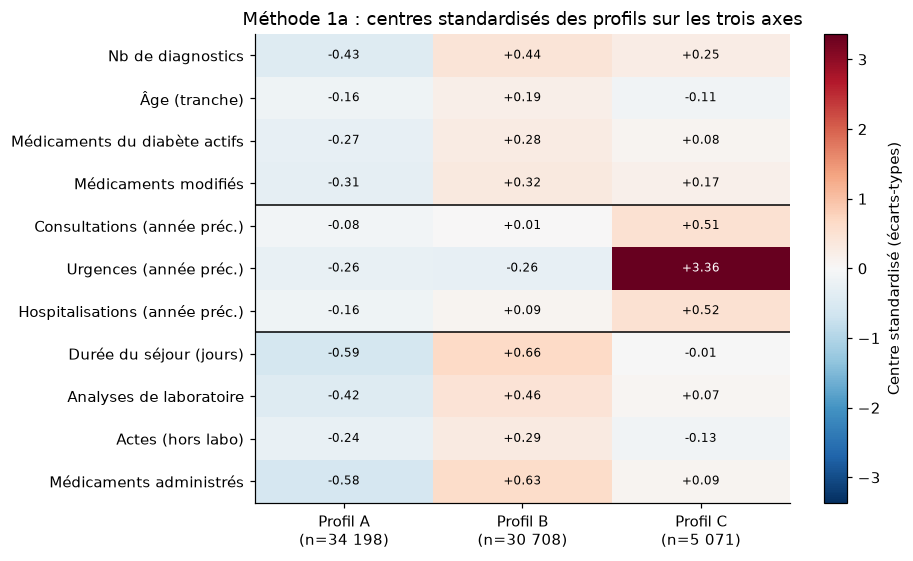

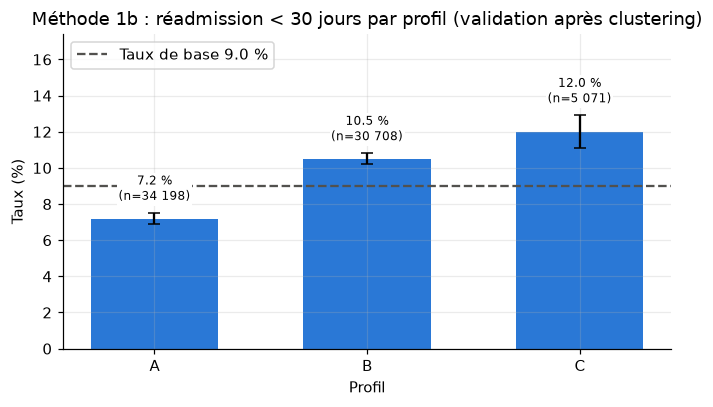

In [22]:
centres = pd.DataFrame(km.cluster_centers_, columns=vars_cluster); centres.index = [lettres[i] for i in range(K)]; centres = centres.sort_index()
fig, ax = plt.subplots(figsize=(1.2 * K + 5, 5.2)); lim = np.abs(centres.values).max()
im = ax.imshow(centres.T.values, cmap="RdBu_r", vmin=-lim, vmax=lim, aspect="auto")
ax.set_xticks(range(K), [f"Profil {c}\n(n={profil.loc[c, 'effectif']:,})".replace(",", " ") for c in centres.index])
ax.set_yticks(range(len(vars_cluster)), [noms_fr[v] for v in vars_cluster])
for i in range(len(vars_cluster)):
    for j in range(K):
        v = centres.T.values[i, j]; ax.text(j, i, f"{v:+.2f}", ha="center", va="center", fontsize=8, color="white" if abs(v) > lim * 0.6 else "black")
for yl in (3.5, 6.5): ax.axhline(yl, color="black", lw=1)
ax.grid(False); fig.colorbar(im, ax=ax, label="Centre standardisé (écarts-types)"); ax.set_title("Méthode 1a : centres standardisés des profils sur les trois axes")
fig.tight_layout(); fig.savefig(OUT / f"{PFX}fig2_profils_centres.png", bbox_inches="tight"); plt.show()

fig, ax = plt.subplots(figsize=(1.1 * K + 3, 3.8))
bars = ax.bar(readm.index, readm["taux (%)"], yerr=readm["marge ± (95 %)"], color=BLEU, width=0.6, capsize=4)
ax.axhline(base_rate * 100, color=GRIS, ls="--", lw=1.5, label=f"Taux de base {base_rate*100:.1f} %")
for b, t, n, e in zip(bars, readm["taux (%)"], readm["effectif"], readm["marge ± (95 %)"]): ax.text(b.get_x() + b.get_width() / 2, t + e + 0.5, f"{t:.1f} %\n(n={n:,})".replace(",", " "), ha="center", va="bottom", fontsize=8, bbox=dict(facecolor="white", edgecolor="none", pad=1))
ax.set(title="Méthode 1b : réadmission < 30 jours par profil (validation après clustering)", xlabel="Profil", ylabel="Taux (%)", ylim=(0, readm["taux (%)"].max() * 1.45)); ax.legend(loc="upper left")
fig.tight_layout(); fig.savefig(OUT / f"{PFX}fig3_readmission_par_profil.png", bbox_inches="tight"); plt.show()

**Méthode 2 : projection par ACP.** Un point par patient, coloré par profil. Chaque plan ne porte qu'environ un tiers
de la variance.

Variance expliquée (%) : [20.3 11.9 11.6  9.7  9.4] | cumul CP1 à CP3 : 43.8 %


,CP1,CP2,CP3
Nb de diagnostics,0.35,-0.38,-0.07
Âge (tranche),0.16,-0.43,-0.24
Médicaments du diabète actifs,0.24,0.44,0.32
Médicaments modifiés,0.27,0.42,0.36
Consultations (année préc.),0.06,-0.31,0.40
Urgences (année préc.),0.05,-0.26,0.54
Hospitalisations (année préc.),0.11,-0.35,0.36
Durée du séjour (jours),0.48,-0.02,-0.15
Analyses de laboratoire,0.34,-0.02,-0.02
Actes (hors labo),0.26,0.10,-0.31


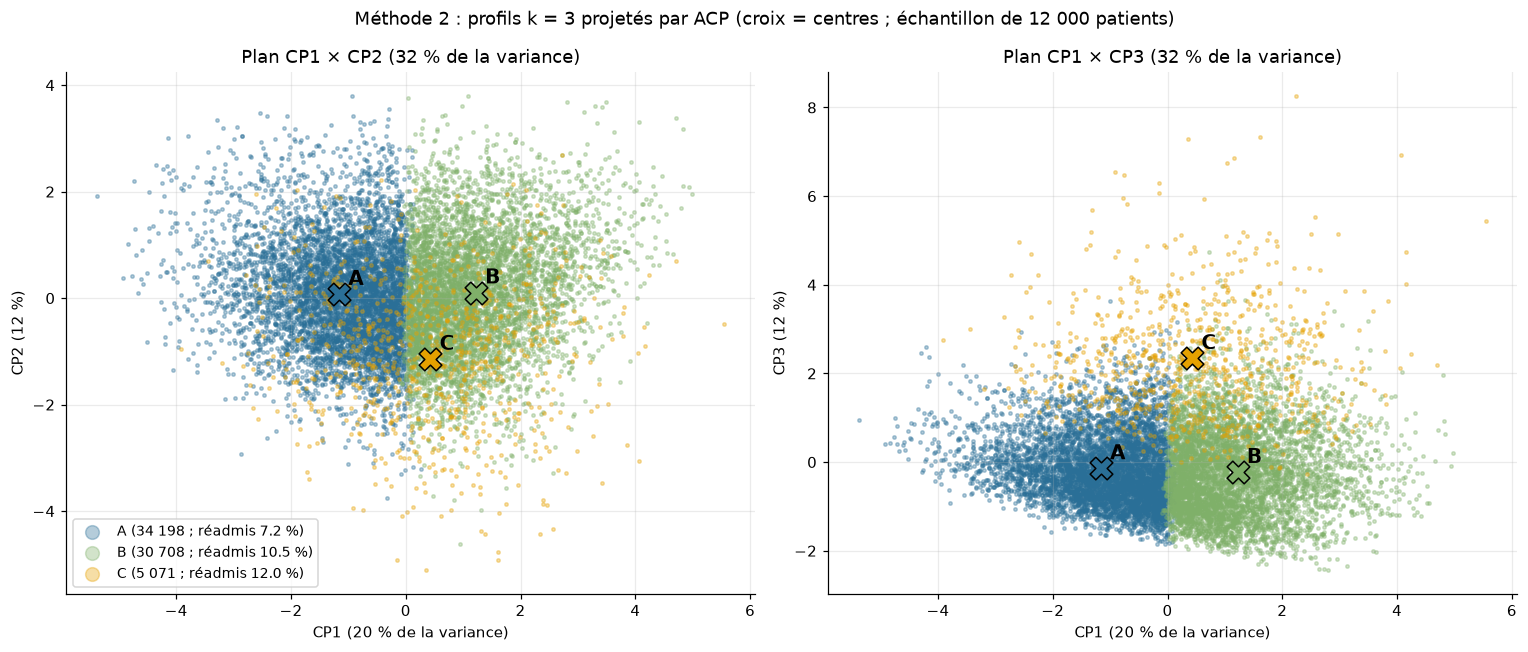

In [23]:
pca = PCA().fit(Z); ve = pca.explained_variance_ratio_; P = pca.transform(Z)[:, :3]; cen = pca.transform(km.cluster_centers_)[:, :3]
print("Variance expliquée (%) :", (ve[:5] * 100).round(1), "| cumul CP1 à CP3 :", round(ve[:3].sum() * 100, 1), "%")
load = pd.DataFrame(pca.components_[:3].T, index=[noms_fr[v] for v in vars_cluster], columns=["CP1", "CP2", "CP3"]).round(2); display(load)
idx = np.random.RandomState(RS).choice(len(Z), 12000, replace=False)
pal = dict(zip(sorted(centres.index), ["#2a6f97", "#7fb069", "#e6a100", "#c1440e", "#7b4fa0", "#3aa6a6", "#888", "#000"]))
fig, axs = plt.subplots(1, 2, figsize=(14, 6))
for ax, (i, j) in zip(axs, [(0, 1), (0, 2)]):
    for L in sorted(centres.index):
        m = (df["profil"].values[idx] == L); ax.scatter(P[idx][m, i], P[idx][m, j], s=5, alpha=.35, color=pal[L], label=f"{L} ({readm.loc[L, 'effectif']:,} ; réadmis {readm.loc[L, 'taux (%)']} %)".replace(",", " "))
    for lab, L in lettres.items():
        ax.scatter(cen[lab, i], cen[lab, j], s=220, marker="X", color=pal[L], edgecolor="black", zorder=5); ax.annotate(L, (cen[lab, i], cen[lab, j]), xytext=(6, 6), textcoords="offset points", fontsize=13, weight="bold")
    ax.set_xlabel(f"CP{i+1} ({ve[i]*100:.0f} % de la variance)"); ax.set_ylabel(f"CP{j+1} ({ve[j]*100:.0f} %)"); ax.set_title(f"Plan CP{i+1} × CP{j+1} ({(ve[i]+ve[j])*100:.0f} % de la variance)")
axs[0].legend(markerscale=4, fontsize=9, loc="lower left"); fig.suptitle(f"Méthode 2 : profils k = {K} projetés par ACP (croix = centres ; échantillon de 12 000 patients)")
fig.tight_layout(); fig.savefig(OUT / f"{PFX}fig4_acp_profils.png", bbox_inches="tight"); plt.show()

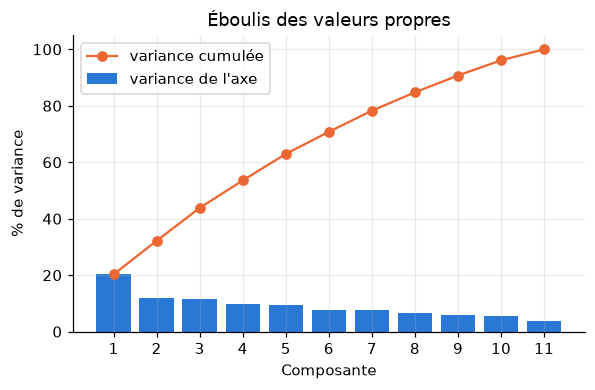

In [24]:
# éboulis des valeurs propres : part de variance portée par chaque composante
cp = np.arange(1, len(ve) + 1)
fig, ax = plt.subplots(figsize=(6, 3.5))
ax.bar(cp, ve * 100, color=BLEU, label="variance de l'axe")
ax.plot(cp, ve.cumsum() * 100, "-o", color=ORANGE, label="variance cumulée")
ax.set(title="Éboulis des valeurs propres", xlabel="Composante", ylabel="% de variance", xticks=cp)
ax.legend()
plt.show()

La méthode 1 décrit exactement les groupes ; la méthode 2 montre leur chevauchement, cohérent avec la silhouette
faible.

Colorée par la cible, la projection ne montre aucune zone de réadmis, seulement un gradient le long de CP1 (volume de
soins du séjour) : de 5,3 % à 12,2 %.

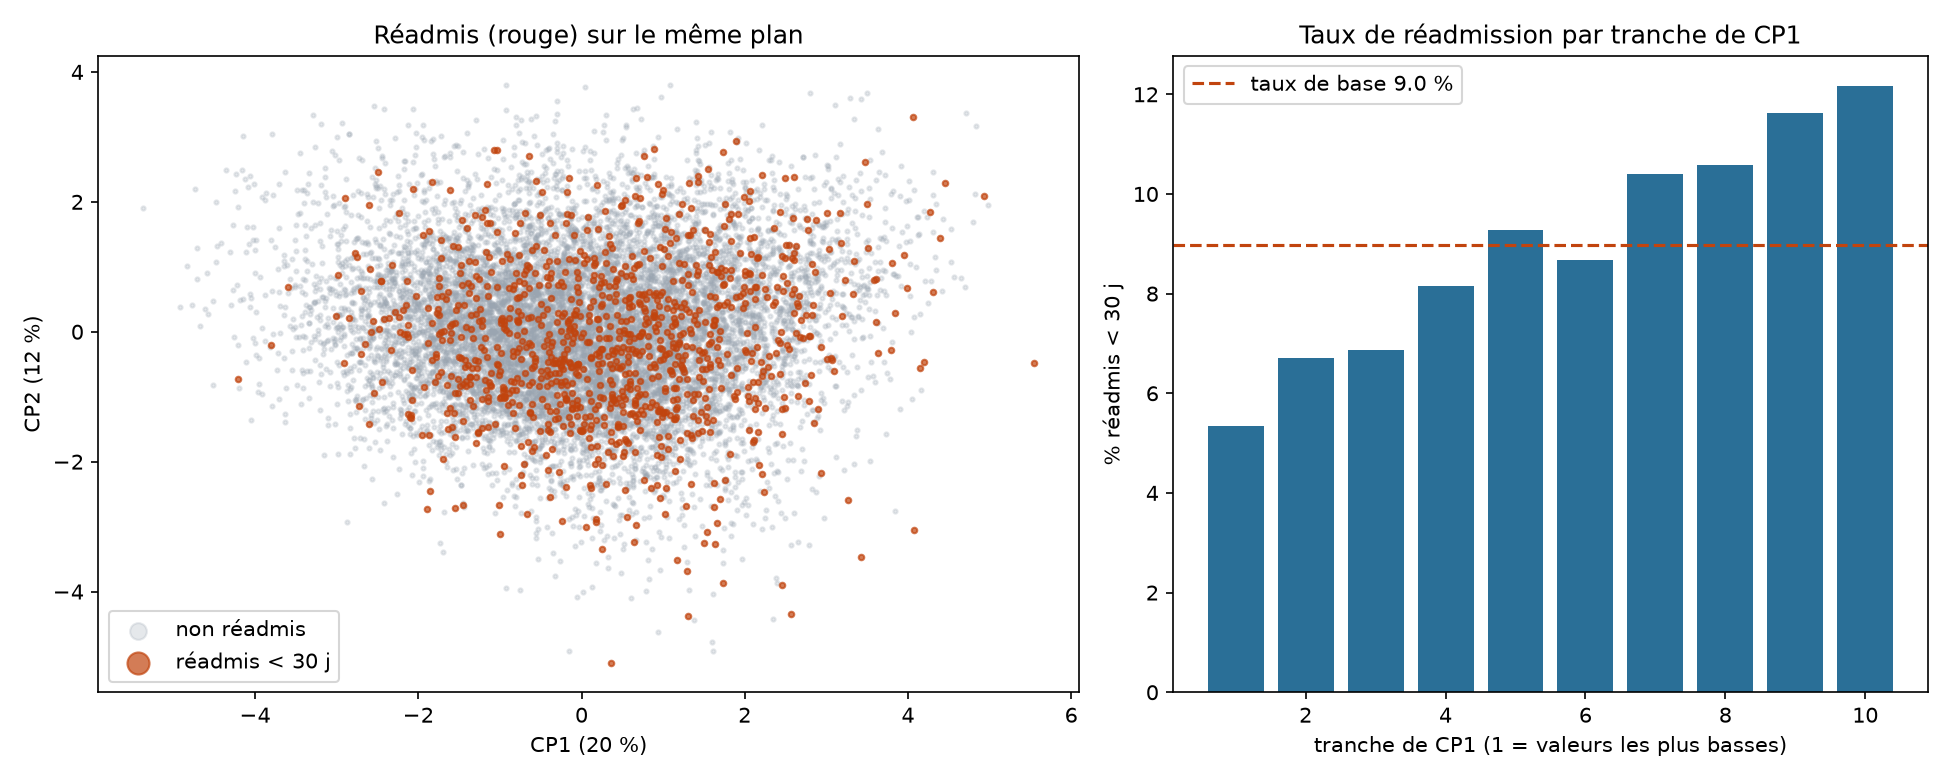

In [25]:
# réadmis dans le plan CP1 × CP2 et taux de réadmission par tranche de CP1
Image(filename=str(OUT / "fig25_acp_readmission.png"), width=900)

### 4.4 Description des profils
Une variable est dite « élevée » ou « faible » quand le centre du profil s'écarte de plus de 0,5 écart-type ;
médianes et moyennes donnent les valeurs réelles.

In [26]:
noms_profils = {"A": "séjours légers", "B": "séjours lourds", "C": "passages aux urgences"} if K == 3 else {}
moy = X_cluster.groupby(df["profil"])[["number_emergency", "number_inpatient"]].mean()
nom = lambda v: noms_fr[v].lower().replace(" (jours)", "")
phrases = []
for c in centres.index:
    hauts = [nom(v) for v in vars_cluster if centres.loc[c, v] > 0.5]
    bas = [nom(v) for v in vars_cluster if centres.loc[c, v] < -0.5]
    desc = ([f"valeurs élevées pour {', '.join(hauts)}"] if hauts else []) + ([f"valeurs faibles pour {', '.join(bas)}"] if bas else []) or ["profil proche de la moyenne sur les trois axes"]
    p = profil.loc[c]
    titre = f"Profil {c}" + (f", {noms_profils[c]}" if c in noms_profils else "")
    effectif = f"{int(p['effectif']):,}".replace(",", " ")
    phrases.append(f"- **{titre}** ({effectif} patients, " + fr(
        f"{p['part (%)']:.1f} %) : {' ; '.join(desc)}. "
        f"Médianes : {p['number_diagnoses']:.0f} diagnostics, {p['num_medications']:.0f} médicaments administrés, séjour de {p['time_in_hospital']:.0f} jours. "
        f"Année précédente, en moyenne : {moy.loc[c, 'number_emergency']:.1f} passage aux urgences, {moy.loc[c, 'number_inpatient']:.1f} hospitalisation. "
        f"Réadmission < 30 j : {readm.loc[c, 'taux (%)']:.1f} % ± {readm.loc[c, 'marge ± (95 %)']:.1f} (base {base_rate*100:.1f} %)."))
display(Markdown("\n".join(phrases)))

- **Profil A, séjours légers** (34 198 patients, 48,9 %) : valeurs faibles pour durée du séjour, médicaments administrés. Médianes : 6 diagnostics, 11 médicaments administrés, séjour de 2 jours. Année précédente, en moyenne : 0,0 passage aux urgences, 0,1 hospitalisation. Réadmission < 30 j : 7,2 % ± 0,3 (base 9,0 %).
- **Profil B, séjours lourds** (30 708 patients, 43,9 %) : valeurs élevées pour durée du séjour, médicaments administrés. Médianes : 9 diagnostics, 19 médicaments administrés, séjour de 6 jours. Année précédente, en moyenne : 0,0 passage aux urgences, 0,2 hospitalisation. Réadmission < 30 j : 10,5 % ± 0,3 (base 9,0 %).
- **Profil C, passages aux urgences** (5 071 patients, 7,2 %) : valeurs élevées pour consultations (année préc.), urgences (année préc.), hospitalisations (année préc.). Médianes : 9 diagnostics, 15 médicaments administrés, séjour de 3 jours. Année précédente, en moyenne : 1,4 passage aux urgences, 0,5 hospitalisation. Réadmission < 30 j : 12,0 % ± 0,9 (base 9,0 %).